In [ ]:
def plot_scenarios(cbm_output_1, cbm_output_2, cbm_output_3, cbm_output_4, n_steps, case_study, obj_mode):
    fig_folder_path = os.path.join('./plots/fig', case_study)
    if not os.path.exists(fig_folder_path):
        os.makedirs(fig_folder_path)
        
    output_filename = f"{case_study}_{obj_mode}_emissions_stocks.pdf"
    output_file_path = os.path.join(fig_folder_path, output_filename)
    fig, axes = plt.subplots(2, 2, sharex=True, figsize=(12, 10))   
    cbm_output_1.groupby('Year').sum().plot(ax=axes[0, 0], xlim=(0, n_steps), ylim=(0, None))
    axes[0, 0].set_title('Carbon stocks over years (alternative scenario)')
    axes[0, 0].set_xlabel('Year')
    axes[0, 0].set_ylabel('Carbon stocks')   
    cbm_output_2.groupby('Year').sum().plot(ax=axes[1, 0], xlim=(0, n_steps))
    axes[1, 0].axhline(y=0, color='red', linestyle='--')
    axes[1, 0].set_title('Carbon emission over years (alternative scenario)')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Carbon emission')
    cbm_output_3.groupby('Year').sum().plot(ax=axes[0, 1], xlim=(0, n_steps), ylim=(0, None))
    axes[0, 1].set_title('Carbon stocks over years (base scenario)')
    axes[0, 1].set_xlabel('Year')
    axes[0, 1].set_ylabel('Carbon stocks')    
    cbm_output_4.groupby('Year').sum().plot(ax=axes[1, 1], xlim=(0, n_steps))
    axes[1, 1].axhline(y=0, color='red', linestyle='--')
    axes[1, 1].set_title('Carbon emission over years (base scenario)')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Carbon emission')    
    plt.tight_layout()
    plt.savefig(output_file_path)
    plt.show()

Columns in the first CSV: Index(['Ecosystem decay emission', 'Gross growth', 'Net emission', 'HWP',
       'Carbon release immediately', 'Concrete_manufacturing',
       'Concrete_landfill'],
      dtype='object')


KeyError: 'Total Ecosystem'

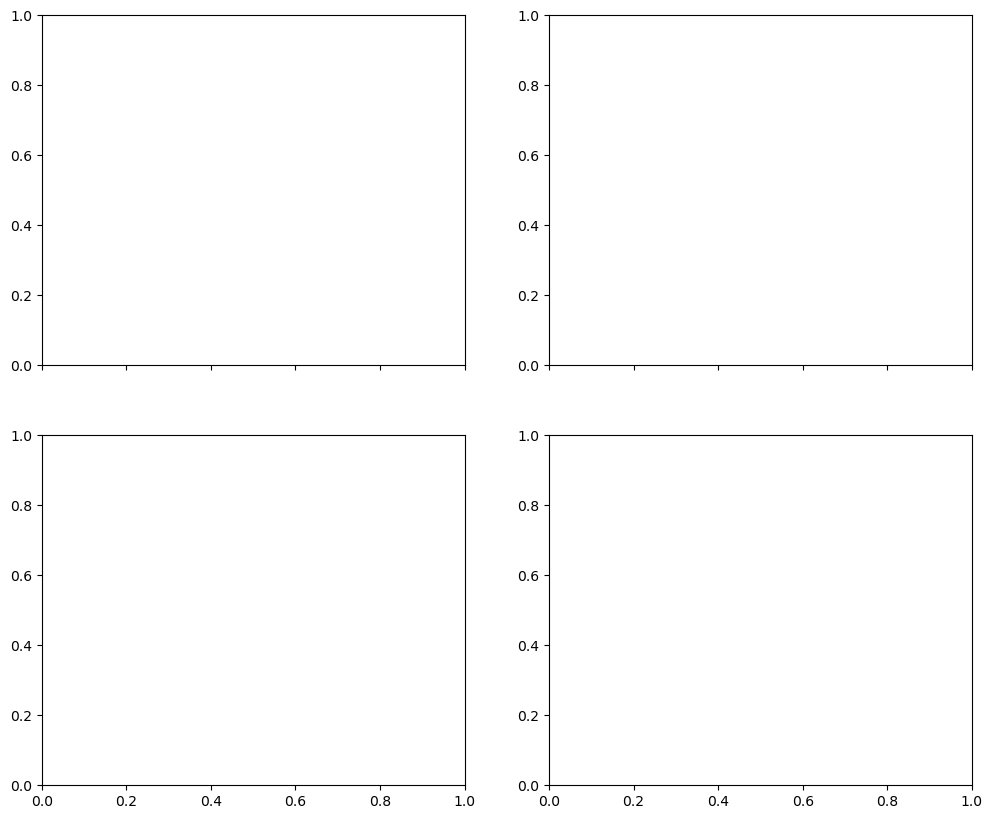

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Function to read data from files and plot the diagrams
def plot_emissions_and_stocks(folder_path, n_steps, case_study, obj_mode):
    # Create a folder for saving plots
    fig_folder_path = os.path.join('./plots/fig', case_study)
    if not os.path.exists(fig_folder_path):
        os.makedirs(fig_folder_path)
        
    # Prepare the output file path
    output_filename = f"{case_study}_{obj_mode}_emissions_stocks.pdf"
    output_file_path = os.path.join(fig_folder_path, output_filename)
    
    # Collect all CSV files in the folder
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    
    # Process each file
    data_frames = []
    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        data_frames.append(df)
    
    # Check column names to confirm the presence of 'Net Emission' and 'Total Ecosystem'
    print("Columns in the first CSV:", data_frames[0].columns)
    
    # Assuming columns 'Net Emission' and 'Total Ecosystem' exist, modify if necessary
    cbm_output_1, cbm_output_2, cbm_output_3, cbm_output_4 = data_frames[:4]
    
    # Assign the index as the year if not already set
    cbm_output_1.index = range(1, len(cbm_output_1) + 1)  # Set row index as year
    cbm_output_2.index = range(1, len(cbm_output_2) + 1)
    cbm_output_3.index = range(1, len(cbm_output_3) + 1)
    cbm_output_4.index = range(1, len(cbm_output_4) + 1)
    
    # Plot diagrams
    fig, axes = plt.subplots(2, 2, sharex=True, figsize=(12, 10))
    
    # Total Ecosystem - Alternative scenario
    cbm_output_1['Total Ecosystem'].plot(ax=axes[0, 0], xlim=(0, n_steps), ylim=(0, None))
    axes[0, 0].set_title('Total Ecosystem Stocks (Alternative)')
    axes[0, 0].set_xlabel('Year')
    axes[0, 0].set_ylabel('Total Ecosystem Stocks')
    
    # Net Emission - Alternative scenario
    cbm_output_2['Net Emission'].plot(ax=axes[1, 0], xlim=(0, n_steps))
    axes[1, 0].axhline(y=0, color='red', linestyle='--')
    axes[1, 0].set_title('Net Emissions (Alternative)')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Net Emissions')
    
    # Total Ecosystem - Base scenario
    cbm_output_3['Total Ecosystem'].plot(ax=axes[0, 1], xlim=(0, n_steps), ylim=(0, None))
    axes[0, 1].set_title('Total Ecosystem Stocks (Base)')
    axes[0, 1].set_xlabel('Year')
    axes[0, 1].set_ylabel('Total Ecosystem Stocks')
    
    # Net Emission - Base scenario
    cbm_output_4['Net Emission'].plot(ax=axes[1, 1], xlim=(0, n_steps))
    axes[1, 1].axhline(y=0, color='red', linestyle='--')
    axes[1, 1].set_title('Net Emissions (Base)')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Net Emissions')
    
    # Adjust layout and save the figure
    plt.tight_layout()
    plt.savefig(output_file_path)
    plt.show()

# Example usage
# Replace 'your_folder_path' with the folder containing the CSV files
plot_emissions_and_stocks(
    folder_path='./plots/equitysilver',  # Folder path to your CSV files
    n_steps=100,  # Replace with the actual number of steps
    case_study='equitysilver',
    obj_mode='max_hv'
)
